## Show what happens for a circular aperture containing Neel vector with an orientation

In [285]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
from IPython.display import display
from vector_ptycho.utils import _to_numpy

device = "cuda" if torch.cuda.is_available() else "cpu"

from vector_ptycho.utils import *
from vector_ptycho.plotting_utils import *
from vector_ptycho.Neel_field_sim_utils import *
from vector_ptycho.reconstruction_utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [286]:
RGB_scale = make_vector_color_map(plot=False)

In [287]:
device = "cuda" if torch.cuda.is_available() else "cpu"
cdtype = torch.complex64
eps = 1e-8

print(device)

cuda


In [304]:
detector_pixel_size = 6.5e-6 * 4 # Pixel size of the detector (after binning)
wavelength = 1.74e-9 # Wavelength of the X-rays (1.74 nm corresponds to 720 eV)
z = 70e-3 # Sample to detector distance
k = 2 * np.pi / wavelength # Wave number
N = 1024 # Number of pixels in the detector
L_detector = N * detector_pixel_size # Detector size

# Define the detector plane coordinates
x_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
y_detector = torch.linspace(-L_detector/2, L_detector/2, N, device=device)
X_detector, Y_detector = torch.meshgrid(x_detector, y_detector, indexing='ij')

# Define the sample plane coordinates
object_pixel_size = (wavelength * z) / (N * detector_pixel_size) # Pixel size in the object/probe plane


L_object = N * object_pixel_size # Object size
x_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
y_obj = torch.linspace(-L_object/2, L_object/2, N, device=device)
X_obj, Y_obj = torch.meshgrid(x_obj, y_obj, indexing='ij')

print(f"Object pixel size: {object_pixel_size:.2e} m")
print(f"Object size: {L_object:.2e} m")

Object pixel size: 4.57e-09 m
Object size: 4.68e-06 m


C:\Users\godfrey\Documents\Ptycho development GPU\vector-ptycho\src\vector_ptycho\plotting_utils.py:340: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  def plot_scan_positions(scan):


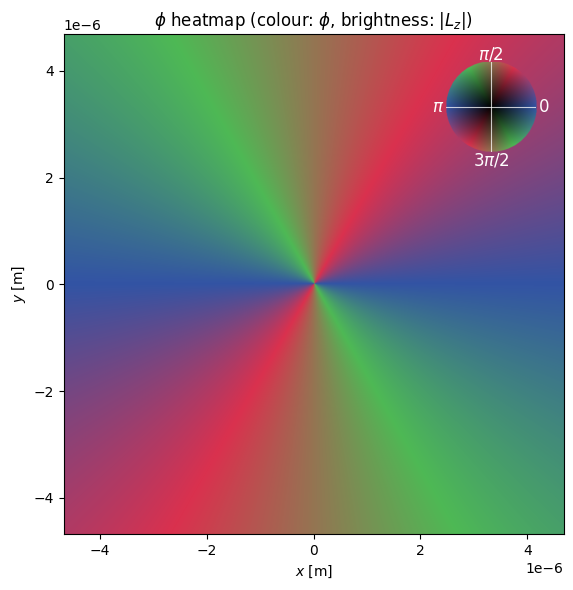

<Figure size 640x480 with 0 Axes>

Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j], device='cuda:0')
Defined 1 probes with different linear polarisation states.


C:\Users\godfrey\Documents\Ptycho development GPU\vector-ptycho\src\vector_ptycho\plotting_utils.py:251: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  """


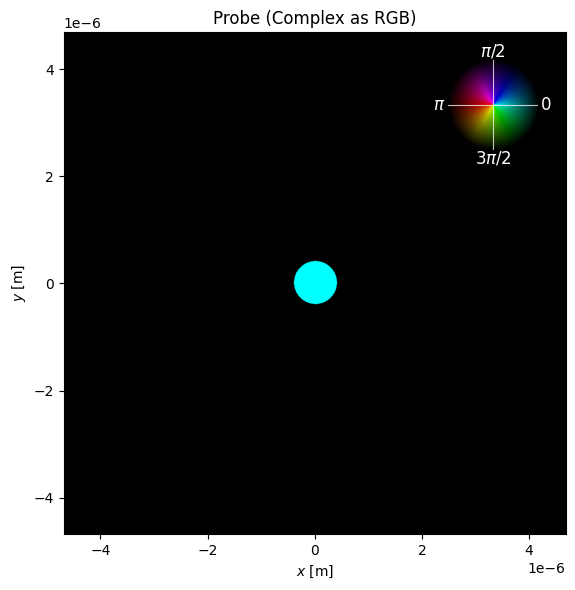

Probe fluence: tensor(100000000., device='cuda:0', dtype=torch.float64)


In [310]:
H, W = N, N
Lx = N * object_pixel_size
Ly = N * object_pixel_size

# Build theta, phi from meron-antimeron generator (returns torch tensors)

theta, phi, Mx, My, Mz = generate_circle(radius=5.5e-6, Nx=N, Ny=N, Lx=Lx, Ly=Ly, plot=True, cm=RGB_scale, device=device)
# Physical XMLD/Jones constants
F0 = torch.tensor(10.0 - 100.0j, dtype=cdtype, device=device)
F1 = torch.tensor(10.0 - 20.0j, dtype=cdtype, device=device)
F2 = torch.tensor(10.0 - 20.0j, dtype=cdtype, device=device)

#F0 = torch.tensor(0.0 + 0.0j, dtype=cdtype, device=device)
#F1 = torch.tensor(0.0 + 0.0j, dtype=cdtype, device=device)
#F2 = torch.tensor(0.0 + 0.0j, dtype=cdtype, device=device)

F_scat = torch.stack([F0, F1, F2])
# Build Jones object from theta, phi
neel = NeelObject(F_scat)
J = neel.build_jones(theta, phi, elements='full')
obj = JonesObject(J)

# Grid for probe definition
#x = torch.linspace(-Lx, Lx, H, device=device)
#y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = X_obj, Y_obj  #torch.meshgrid(x, y, indexing='ij')

# Define a probe with some phase structure on the wavefront.
fluence = torch.scalar_tensor(1e8, dtype=torch.float64, device=device)
R=torch.sqrt(X**2+Y**2) #This helps with defining the probe
R_probe = 0.2e-6 # Radius of the probe in meters
Diffuser = 0.1*(torch.sin(1*R)+torch.cos((Y*5+X*1)-0.8*(X-0.2))+torch.cos((Y-X)-0.4*(X)))*(R<R_probe) #(torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)#*(torch.exp(-0.1*R)) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)
Diffuser = 0.0*R#1e13*R**2*(R<R_probe)
P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(R<R_probe)#*(torch.exp(-0.8*R))

# Calculate the Jones vectors of the probes for different Linear polarisation states
probes = []
pol_angles = [0]#, 120, 150, 180]

for angle in pol_angles:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec, fluence=fluence, normalized=False))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))


plot_probe_maps(probes[0].amplitude, Lx, Ly)
print('Probe fluence:', probes[0].fluence)

Positions after adding shifts: torch.Size([1, 1, 2])


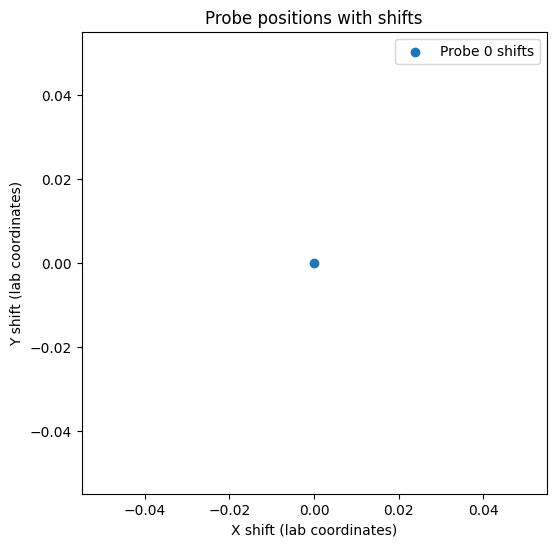

In [309]:


# Convert lab coordinates into discrete pixel shifts for torch.roll(row, col)
pixel_size_y = (2 * Ly) / (H - 1)
pixel_size_x = (2 * Lx) / (W - 1)

positions = torch.tensor([[[0.0, 0.0]]], device=device) # Define the scan positions in meters (x, y)

# Create a ScanTrajectory object with the positions for each probe
scan = ScanTrajectory(positions, shifts=None)
plot_scan_positions(scan)

# Forward model
model = ForwardModel(obj, Propagator(), Detector(add_poisson_noise=True))
I_sim = model.simulate_all(probes, scan)

C:\Users\godfrey\AppData\Local\Temp\ipykernel_27600\1823838419.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(I_sim[0, 0].cpu()+1e-8),


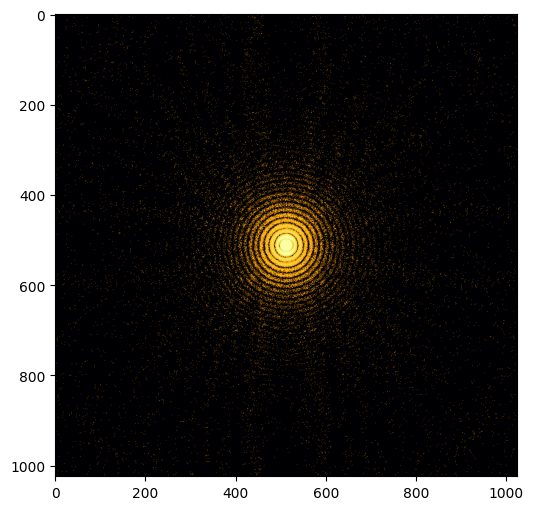

In [299]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

ax.imshow(
    np.log10(I_sim[0, 0].cpu()+1e-8),
    cmap='inferno',
    vmin=-7, vmax=2
)

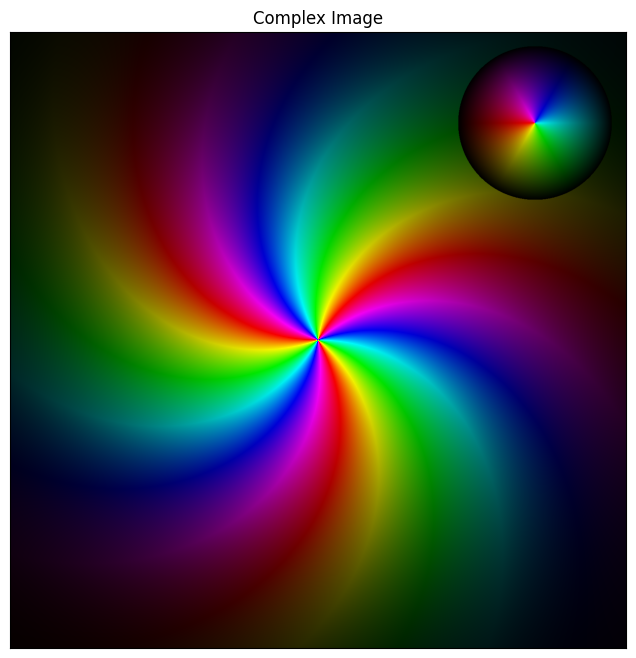

In [281]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ------------------------------------------------------------
# Complex -> RGB conversion
# hue        = phase
# brightness = magnitude
# ------------------------------------------------------------
def complex_to_rgb(Z, gamma=0.7):
    amp = np.abs(Z)
    phase = np.angle(Z)

    amp = amp / amp.max()
    amp = amp**gamma

    h = (phase + np.pi) / (2 * np.pi)
    s = np.ones_like(h)
    v = amp

    hsv = np.stack([h, s, v], axis=-1)
    return hsv_to_rgb(hsv)


# ------------------------------------------------------------
# Example complex image
# ------------------------------------------------------------
N = 600
x = np.linspace(-4, 4, N)
y = np.linspace(-4, 4, N)
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

Z = np.exp(-(R**2)/6) * np.exp(1j * (3*Theta + 0.7*R))

rgb = complex_to_rgb(Z)

# ------------------------------------------------------------
# Main figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(rgb, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()])
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Complex Image")

# ------------------------------------------------------------
# Transparent inset axis
# ------------------------------------------------------------
axins = inset_axes(
    ax,
    width="25%",
    height="25%",
    loc='upper right',
    borderpad=1
)

axins.set_facecolor((0, 0, 0, 0))  # transparent background

# ------------------------------------------------------------
# Colour wheel
# ------------------------------------------------------------
Nw = 400
u = np.linspace(-1, 1, Nw)
v = np.linspace(-1, 1, Nw)
U, V = np.meshgrid(u, v)

Rw = np.sqrt(U**2 + V**2)
Phiw = np.arctan2(V, U)

# Brightness decreases with radius
magnitude = 1 - Rw
magnitude = np.clip(magnitude, 0, 1)

Zw = magnitude * np.exp(1j * Phiw)

wheel_rgb = complex_to_rgb(Zw, gamma=1.0)

# RGBA image with transparent outside
alpha = np.ones_like(Rw)
alpha[Rw > 1] = 0.0

wheel_rgba = np.dstack([wheel_rgb, alpha])

axins.imshow(
    wheel_rgba,
    origin='lower',
    extent=[-1, 1, -1, 1]
)

axins.set_xticks([])
axins.set_yticks([])

# Remove inset frame
for spine in axins.spines.values():
    spine.set_visible(False)

plt.show()
